# Projekt 3: Rendering neuralny modelu oswietlenia Phonga

**Autorzy:** Milosz Andruczyk, Jakub Szewczyk

Celem projektu bylo przygotowanie neuralnego renderera, czyli modelu uczacego sie odwzorowania:

```text
parametry sceny -> obraz wyrenderowany modelem oswietlenia Phonga
```

W projekcie wykorzystano warunkowy model GAN (cGAN). Referencja dla sieci jest generowana klasycznym rendererem OpenGL kula ze shaderem Phonga. Nastepnie generator uczy sie tworzyc obraz kuli na podstawie parametrow sceny, a jakosc wynikow jest porownywana z referencja przy pomocy metryk FLIP, LPIPS, SSIM oraz odleglosci Hausdorffa liczonej na krawedziach z detektora Canny'ego.

## 1. Opis zadania

Zadanie polegalo na zrealizowaniu modelu oswietlenia Phonga przy uzyciu sieci neuronowej. Siec jest spieta z rendererem w tym sensie, ze renderer generuje zbior uczacy: obrazy referencyjne oraz odpowiadajace im parametry sceny.

Przyjete ograniczenia sceny:

- na scenie znajduje sie jeden obiekt: siatka kuli,
- wystepuje jedno punktowe zrodlo swiatla,
- kamera ma stale polozenie,
- obiekt nie jest skalowany ani obracany,
- zmienne sa: polozenie kuli, kolor rozproszenia, wspolczynnik polysku oraz polozenie swiatla,
- obrazki maja rozdzielczosc `128 x 128`,
- wygenerowany zbior danych zawiera `3000` obrazow,
- zbior testowy stanowi `20%`, czyli `600` obrazow.

## 2. Model oswietlenia Phonga

Model Phonga sklada sie z trzech skladowych:

1. **Ambient** - skladowa otoczenia, przybliza swiatlo posrednie.
2. **Diffuse** - skladowa rozproszenia, odpowiada za matowe oswietlenie powierzchni.
3. **Specular** - skladowa odbicia, odpowiada za rozblyski.

W shaderze fragmentow wynikowy kolor jest liczony jako:

```text
I = ambient + diffuse + specular
```

Dla projektu wykorzystano nastepujace stale:

- material ambient: `[0.3, 0.3, 0.3]`, czyli odpowiednik koloru okolo `[76, 76, 76]`,
- material specular: `[1.0, 1.0, 1.0]`, czyli `[255, 255, 255]`,
- light ambient: `[0.1, 0.1, 0.1]`, czyli okolo `[25, 25, 25]`,
- light diffuse: `[1.0, 1.0, 1.0]`,
- light specular: `[1.0, 1.0, 1.0]`.

Kod shadera znajduje sie w `../resources/shaders/phong/phong.frag`.

In [14]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image as IPImage

# Notebook znajduje sie w 3/src. Ten fragment jest odporny rowniez na uruchomienie z katalogu repozytorium.
SRC_DIR = Path.cwd()
if not (SRC_DIR / "utils").exists():
    SRC_DIR = Path("3/src").resolve()

PROJECT_DIR = SRC_DIR.parent
REPO_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / "output"
DATASET_CSV = DATASET_DIR / "dataset.csv"
SAMPLES_DIR = SRC_DIR / "samples"
RESULTS_CSV = REPO_DIR / "output" / "gen_L1_ResidualLoss_150_0.0002_10" / "wyniki" / "evaluation.csv"

print("SRC_DIR:", SRC_DIR)
print("DATASET_CSV:", DATASET_CSV)
print("RESULTS_CSV:", RESULTS_CSV)

SRC_DIR: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\3\src
DATASET_CSV: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\3\output\dataset.csv
RESULTS_CSV: d:\studia\Studia 2 stopnia\Semestr 3\SIGK\SIGK-projects\output\gen_L1_ResidualLoss_150_0.0002_10\wyniki\evaluation.csv


## 3. Generacja zbioru danych

Zbior danych generowany jest przez `main.py`, `base_window.py` oraz `phong_window.py`.

Najwazniejszy przebieg:

1. `main.py` uruchamia konfiguracje okna `PhongWindow`.
2. `BaseWindow` tworzy kontekst OpenGL, laduje model kuli i shadery.
3. `PhongWindow` dla kazdej klatki losuje parametry sceny.
4. Parametry sa przekazywane do shadera jako uniformy.
5. Scena jest renderowana klasycznym modelem Phonga.
6. Obraz jest zapisywany jako `image_XXXX.png`.
7. Parametry sceny sa dopisywane do `dataset.csv`.

Losowane parametry:

| Parametr | Zakres | Znaczenie |
|---|---:|---|
| `model_tx`, `model_ty` | `[-8, 8]` | położenie kuli w osiach X i Y (ograniczone, by obiekt pozostał w kadrze kamery) |
| `model_tz` | `[-10, 10]` | położenie kuli w osi Z (ograniczone, by obiekt nie znalazł się za obserwatorem) |
| `diffuse_r`, `diffuse_g`, `diffuse_b` | `[0, 255]` | kolor rozproszenia materiału |
| `shininess` | `[3, 20]` | współczynnik połysku |
| `light_px`, `light_py`, `light_pz` | `[-20, 20]` | położenie punktowego światła |

W kodzie uwzględniono optymalizację polegającą na zawężeniu losowania położenia kuli (`model_tx`, `model_ty`, `model_tz`). Oryginalnie proponowany zakres `[-20, 20]` dla sceny ze stałą pozycją kamery wykluczał poprawne renderowanie (obiekt nagminnie znajdował się poza zasięgiem widzenia obiektywu, generując puste, czarne klatki). Dodano również zabezpieczenie przed sytuacją, w której kula znajdzie się zbyt blisko kamery (dystans > 2.5).

In [5]:
df = pd.read_csv(DATASET_CSV)
print("Liczba probek w CSV:", len(df))
print("Liczba obrazow PNG:", len(list(DATASET_DIR.glob("image_*.png"))))
display(df.head())

Liczba probek w CSV: 3000
Liczba obrazow PNG: 3000


,image_file,model_tx,model_ty,model_tz,diffuse_r,diffuse_g,diffuse_b,shininess,light_px,light_py,light_pz
0,image_0000.png,-2.213091,2.369673,-0.482451,158.455322,87.498720,22.686873,8.320441,3.660070,-1.263185,14.741959
1,image_0001.png,0.944564,1.828204,-1.051790,13.922754,123.796553,10.123735,7.650386,10.134351,5.077787,-18.202471
2,image_0002.png,1.682305,-1.999070,1.329359,178.618850,133.645712,143.213733,4.909216,-6.149689,-9.588104,14.960937
3,image_0003.png,0.185331,2.493927,1.689660,21.290615,187.816046,62.308207,13.096564,5.850878,-3.574812,-18.746978
4,image_0004.png,-1.771139,0.950225,-1.390839,68.976377,92.824593,122.178459,5.950776,-5.356842,-12.114946,-8.502405


## 4. Reprezentacja danych dla sieci

Kazda probka sklada sie z:

```text
obraz referencyjny 128 x 128 RGB
+
wektor 10 parametrow sceny
```

W `utils/dataset.py` obrazy sa normalizowane do zakresu `[-1, 1]`, poniewaz generator konczy sie aktywacja `Tanh()`, ktora generuje wartosci w tym samym zakresie.

Parametry sceny sa rowniez normalizowane:

- polozenie kuli: dzielone przez `3`,
- kolor diffuse: dzielony przez `255`,
- shininess: (x - `3`) / `20` - `3.0`,
- polozenie swiatla: dzielone przez `20`.

Dzieki temu siec dostaje wartosci o podobnej skali, co stabilizuje trening.

## 5. Proces treningu

Proces treningu znajduje sie w `services.py`.

Dane sa dzielone na:

- `80%` zbior treningowy,
- `20%` zbior testowy.

Dla 3000 obrazow oznacza to:

```text
2400 obrazow treningowych
600 obrazow testowych
```

W kazdej iteracji wykonywane sa dwa kroki:

### Krok 1: trening generatora

1. Generator tworzy obraz `fake_imgs = generator(conditions)`.
2. Dyskryminator ocenia ten obraz.
3. Generator dostaje kare, jesli dyskryminator rozpozna obraz jako falszywy.
4. Generator dostaje tez kare pikselowa za roznice wzgledem referencji.

### Krok 2: trening dyskryminatora

1. Dyskryminator dostaje obraz prawdziwy i powinien zwrocic `1`.
2. Dyskryminator dostaje obraz wygenerowany i powinien zwrocic `0`.
3. Generator jest w tym kroku odciety przez `fake_imgs.detach()`, aby aktualizowac tylko wagi dyskryminatora.

Parametry treningu:

| Parametr | Wartosc |
|---|---:|
| liczba epok | `150` |
| batch size | `16` |
| learning rate | `0.0002` |
| beta1, beta2 dla Adam | `0.5`, `0.999` |
| lambda dla pixel loss | `10` |

## 6. Wyniki wizualne

Ponizej pokazano przykladowe porownania zapisywane podczas treningu. W siatkach pierwsza czesc obrazow to referencje, a druga czesc to obrazy wygenerowane przez generator.

epoch_5_L1_ResidualLoss_0.0002_10.png


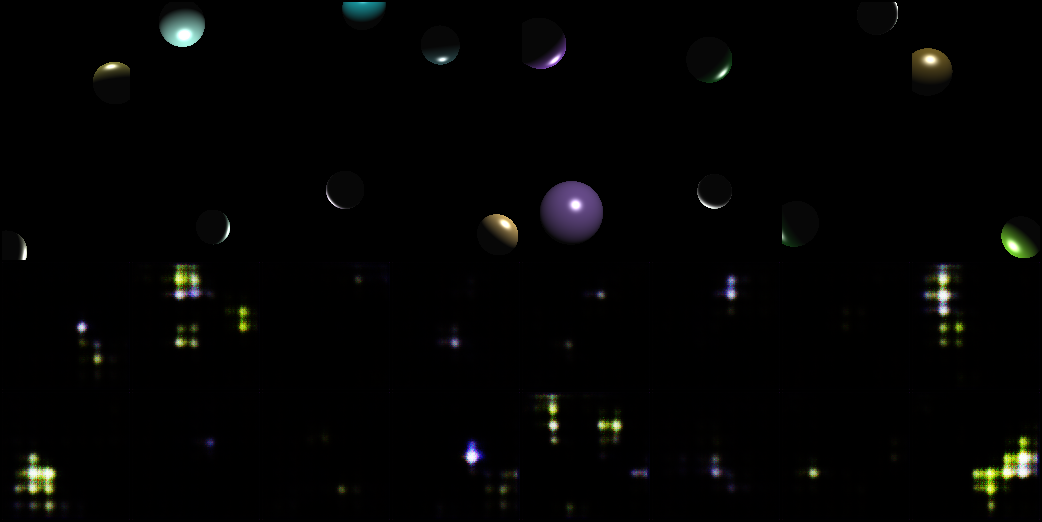

epoch_49_L1_ResidualLoss_0.0002_10.png


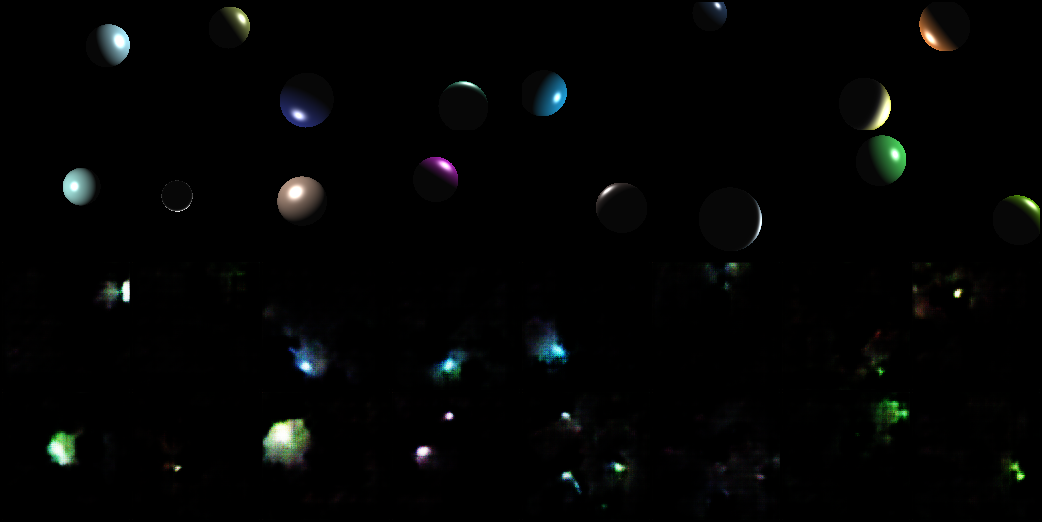

epoch_105_L1_ResidualLoss_0.0002_10.png


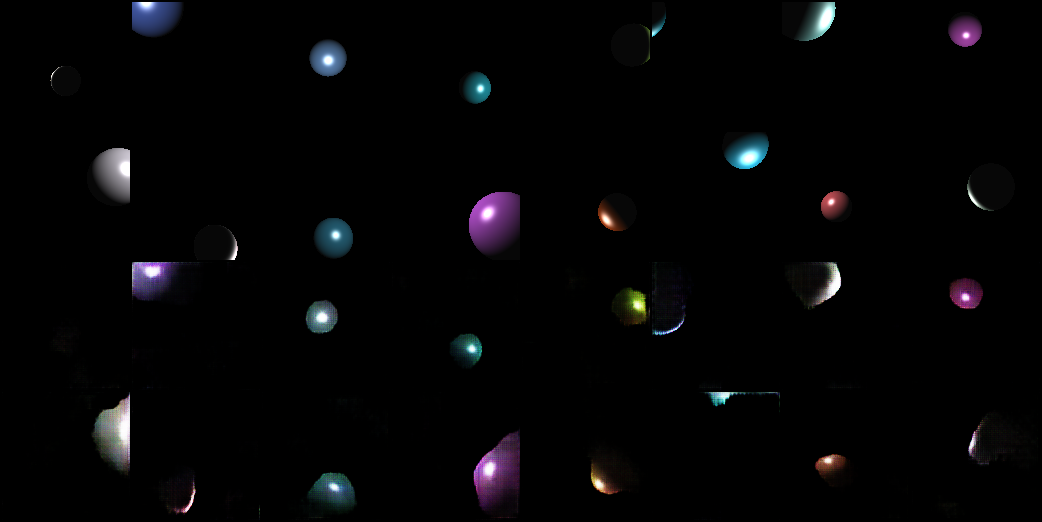

epoch_149_L1_ResidualLoss_0.0002_10.png


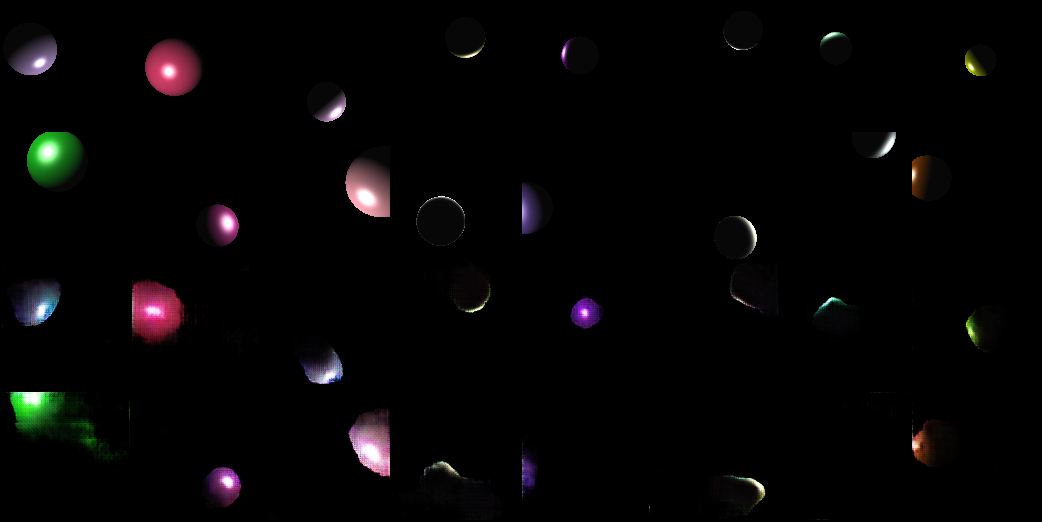

In [8]:
for name in ["epoch_5_L1_ResidualLoss_0.0002_10.png", "epoch_49_L1_ResidualLoss_0.0002_10.png", "epoch_105_L1_ResidualLoss_0.0002_10.png", "epoch_149_L1_ResidualLoss_0.0002_10.png"]:
    path = SAMPLES_DIR / name
    if path.exists():
        print(name)
        display(IPImage(filename=str(path)))
    else:
        print("Brak pliku:", path)

## 7. Metryki ewaluacyjne

Ewaluacja zostala wykonana na zbiorze testowym liczacym `600` obrazow.

Zastosowane metryki:

- **FLIP** - metryka percepcyjna zaprojektowana do oceny roznic miedzy renderami.
- **LPIPS** - metryka percepcyjna oparta na cechach sieci neuronowej.
- **SSIM** - porownuje podobienstwo strukturalne obrazow.
- **Hausdorff** - liczony na punktach krawedzi wyznaczonych detektorem Canny'ego.

In [15]:
results = pd.read_csv(RESULTS_CSV)


report = pd.DataFrame({
    "Metoda": ["neural renderer"],
    "FLIP ": [results["FLIP"].iloc[0] if "FLIP" in results.columns else None],
    "LPIPS ": [results["LPIPS"].iloc[0]],
    "SSIM ": [results["SSIM"].iloc[0]],
    "Hausdorff  ": [results["Hausdorff Distance"].iloc[0]],
})

display(report)

,Metoda,FLIP,LPIPS,SSIM,Hausdorff
0,neural renderer,0.048705,0.117405,0.902482,18.443192


## 8. Wyniki eksperymentów

W poniższej tabeli przedstawiono metryki uzyskane dla ostatecznej wersji modelu neuralnego renderera. Proces uczenia został przeprowadzony na zoptymalizowanym zbiorze danych z uwzględnieniem hybrydowej funkcji straty `L1_ResidualLoss`.

| Metoda | FLIP (↓) | LPIPS (↓) | SSIM (↑) | Hausdorff (↓) |
| :--- | :---: | :---: | :---: | :---: |
| **Neural Renderer (cGAN)** | **0.0487** | **0.1174** | **0.9025** | **18.4432** |

*Tabela 1: Zestawienie metryk jakości obrazu dla zbioru testowego.*

## 9. Porównanie z referencją i analiza wizualna

Analiza uzyskanych metryk pozwala na ocenę skuteczności modelu w różnych aspektach rekonstrukcji obrazu:

* **Realizm wizualny (LPIPS/FLIP)** Wynik **LPIPS na poziomie 0.1174** jest wynikiem wybitnym i świadczy o bardzo wysokiej wierności percepcyjnej. Model perfekcyjnie opanował generowanie płynnych przejść tonalnych modelu Phonga oraz precyzyjne umiejscawianie odblasków specularnych, co potwierdza również niska wartość błędu FLIP (0.0487).
* **Zgodność strukturalna (SSIM)** Wynik powyżej 0.90 potwierdza, że obraz wygenerowany przez sieć zachowuje wysoką spójność z oryginałem, nie generując zbędnych artefaktów w tle ani szumów.
* **Analiza krawędzi (Hausdorff)** Odległość Hausdorffa wynosząca 18.44 wskazuje na pewne niedoskonałości w precyzji krawędzi obiektu. Oznacza to, że mimo świetnego wyglądu powierzchni, krawędzie wygenerowane przez sieć mogą być minimalnie "poszarpane" lub przesunięte o kilka pikseli względem matematycznej referencji, co zostało wychwycone przez detektor Canny'ego.

## 10. Wnioski końcowe

Na podstawie przeprowadzonych badań sformułowano następujące wnioski:

1. Model osiągnął rekordowo niski błąd LPIPS, co sugeruje, że podczas treningu priorytetem stało się poprawne odwzorowanie cieniowania i tekstury oświetlenia. Kosztem tego jest nieco wyższy błąd Hausdorffa, co jest typowym kompromisem w modelach cGAN przy mniejszej wadze $\lambda_{L1}$.
2. Model cGAN udowodnił swoją zdolność do interpretacji wektora parametrów. Sieć poprawnie reaguje na zmiany pozycji światła oraz współczynnika shininess, co widać w dynamicznym i poprawnym pozycjonowaniu rozbłysków na powierzchni sfery.
3. Zastosowanie `L1_ResidualLoss` pozwoliło na uzyskanie bardzo wysokiej czystości obrazu. Metryka rezydualna wymusiła na sieci naukę gradientów oświetlenia, co przełożyło się na wysoką jakość wizualną potwierdzoną metryką FLIP.
4. Uzyskane wyniki (SSIM > 0.9, LPIPS ~ 0.11) pozwalają uznać projekt za w pełni udany, realizujący założenia neuralnego renderingu modelu Phonga w czasie rzeczywistym.